### Cuaderno: Locked-image Text tuning (LiT), InfoNCE y Comparación de Arquitecturas
Este cuaderno explora el paradigma LiT (Locked-image Text tuning). A diferencia del entrenamiento CLIP estándar donde ambas torres se actualizan, LiT congela (bloquea) un modelo de imagen preentrenado poderoso y solo entrena la torre de texto para que sus representaciones se alineen con el espacio visual existente.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
import torchvision.models as models
from torchvision.models import ResNet18_Weights, ViT_B_16_Weights
from datasets import load_dataset
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Carga de datos simplificada basada en Flickr8k
dataset = load_dataset("jxie/flickr8k")

class SimpleFlickrDataset(Dataset):
    def __init__(self, hf_dataset, split="train", limit=200):
        self.data = hf_dataset[split][:limit]
        
    def __len__(self):
        return len(self.data["image"])
        
    def __getitem__(self, idx):
        return {
            "image": self.data["image"][idx].convert("RGB"),
            "caption": self.data["caption_0"][idx] # Usamos solo la primera caption
        }

train_ds = SimpleFlickrDataset(dataset, "train", limit=400)
val_ds = SimpleFlickrDataset(dataset, "validation", limit=100)
test_ds = SimpleFlickrDataset(dataset, "test", limit=100)

C:\Users\roaml\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


Para esta experimentación usaremos varios modelos para obtener el mejor experimentalmente, para hacer comparaciones y uso del grid search, para comparar multiples arquitecturas y el parametro de temperatura de InfoNCE
<p align="center">
  <img src="./experimento.png" width="600px" alt="Image from paper LiT">
</p>


In [2]:
# --- MODELOS DE IMAGEN (CONGELADOS) ---

class ImageCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.proj = nn.Linear(resnet.fc.in_features, embed_dim)
        
    def forward(self, x):
        features = self.backbone(x).flatten(1)
        return F.normalize(self.proj(features), dim=-1)

class ImageTransformer(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        vit = models.vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        vit.heads = nn.Identity() 
        self.backbone = vit
        self.proj = nn.Linear(768, embed_dim)
        
    def forward(self, x):
        features = self.backbone(x)
        return F.normalize(self.proj(features), dim=-1)

#Modelos texto

class TextEncoderModel(nn.Module):
    """Arquitectura general para BERT/DistilBERT (Encoder)"""
    def __init__(self, model_name, embed_dim=256):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.proj = nn.Linear(self.encoder.config.hidden_size, embed_dim)
        
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = out.last_hidden_state[:, 0, :] # Tomamos el token [CLS]
        return F.normalize(self.proj(cls_token), dim=-1)

class TextDecoderModel(nn.Module):
    """Arquitectura adaptada para GPT-2 (Decoder)"""
    def __init__(self, model_name, embed_dim=256):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        # GPT-2 no tiene token de padding por defecto, se configurará en el tokenizador
        self.proj = nn.Linear(self.encoder.config.hidden_size, embed_dim)
        
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # En modelos causales, tomamos la representación del último token de la secuencia
        batch_size = input_ids.shape[0]
        sequence_lengths = attention_mask.sum(dim=1) - 1
        last_tokens = out.last_hidden_state[torch.arange(batch_size), sequence_lengths]
        return F.normalize(self.proj(last_tokens), dim=-1)

### Fórmulas de Pérdida InfoNCE

**Pérdida de Imagen a Texto (Image-to-Text Loss):**
$$ \mathcal{L}_{I \rightarrow T} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(\text{sim}(I_i, T_i) / \tau)}{\sum_{j=1}^{N} \exp(\text{sim}(I_i, T_j) / \tau)} $$

**Pérdida de Texto a Imagen (Text-to-Image Loss):**
$$ \mathcal{L}_{T \rightarrow I} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(\text{sim}(T_i, I_i) / \tau)}{\sum_{j=1}^{N} \exp(\text{sim}(T_j, I_i) / \tau)} $$

**Pérdida Total:**
$$ \mathcal{L}_{\text{total}} = \frac{\mathcal{L}_{I \rightarrow T} + \mathcal{L}_{T \rightarrow I}}{2} $$

**Dónde:**
* $N$: Tamaño del batch (*batch size*).
* $I_i$: Embedding de la imagen del par $i$.
* $T_i$: Embedding del texto del par $i$.
* $\text{sim}(\cdot, \cdot)$: Función de similitud (como el producto punto o similitud coseno).
* $\tau$: Parámetro de temperatura.

<p align="center">
  <img src="https://miro.medium.com/1*4vDX5iwLA54BI5wuqThOvw.png" alt="Image from paper LiT">
</p>


In [3]:
class LiTModel(nn.Module):
    def __init__(self, image_model, text_model, temperature=0.07):
        super().__init__()
        self.image_model = image_model
        self.text_model = text_model
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / temperature))
        
        # Bloquear pesos de la imagen (Lock Image)
        for param in self.image_model.parameters():
            param.requires_grad = False

    def forward(self, images, input_ids, attention_mask):
        with torch.no_grad(): # Garantizar que no fluyan gradientes por la imagen
            image_features = self.image_model(images)
            
        text_features = self.text_model(input_ids, attention_mask)
        
        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()
        
        return logits_per_image, logits_per_text

def infonce_loss(logits_per_image, logits_per_text):
    labels = torch.arange(logits_per_image.shape[0], device=logits_per_image.device)
    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)
    return (loss_i + loss_t) / 2

#### Train y evaluate
Para la metrica de evaluación usaremos: R@k(Recall at k), nos permite saber que tan probable es encontrar la pareja correcta en los primeros k resultados sugeridos por el modelo.

In [4]:
from torchvision import transforms

def collate_fn(batch, tokenizer, img_transform):
    images = torch.stack([img_transform(item["image"]) for item in batch])
    texts = [item["caption"] for item in batch]
    tokens = tokenizer(texts, padding=True, truncation=True, max_length=40, return_tensors="pt")
    return images, tokens["input_ids"], tokens["attention_mask"]
def get_model_image(model_name):
    if model_name == "CNN":
        return ImageCNN().to(DEVICE), transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    else:
        return ImageTransformer().to(DEVICE), transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
def get_model_text(model_name, text_arch_type):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    if text_arch_type == "encoder":
        return TextEncoderModel(model_name).to(DEVICE), tokenizer
    else:
        return TextDecoderModel(model_name).to(DEVICE), tokenizer
def train_model_epoch(model, train_loader, optimizer, epochs=2):
    model.train()
  
    total_loss = 0
    for imgs, ids, masks in train_loader:
        imgs, ids, masks = imgs.to(DEVICE), ids.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits_i, logits_t = model(imgs, ids, masks)
        loss = infonce_loss(logits_i, logits_t)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss 
def evaluate_model(model, test_loader):
    model.eval()
    test_loss = 0
    all_img_features = []
    all_txt_features = []
    
    with torch.no_grad():
        for imgs, ids, masks in test_loader:
            imgs, ids, masks = imgs.to(DEVICE), ids.to(DEVICE), masks.to(DEVICE)
            
            img_feat = model.image_model(imgs)
            txt_feat = model.text_model(ids, masks)
            logit_scale = model.logit_scale.exp()
            logits_i = logit_scale * img_feat @ txt_feat.t()
            logits_t = logits_i.t()
            test_loss += infonce_loss(logits_i, logits_t).item()
            all_img_features.append(img_feat.cpu())
            all_txt_features.append(txt_feat.cpu())
            
    # Concatenar todos los embeddings (Forma esperada: N x embed_dim)
    full_img_feats = torch.cat(all_img_features, dim=0)
    full_txt_feats = torch.cat(all_txt_features, dim=0)
    
    # Matriz de similitud global (Forma esperada: N x N)
    sim_matrix = full_img_feats @ full_txt_feats.t()
    labels = torch.arange(sim_matrix.size(0))
    
    # Cálculo de métricas básicas top-K sobre todo el test set
    metrics = {"Test_Loss": test_loss/len(test_loader)}
    for k in [1, 5, 10]:
        # min(k, tamaño) asegura que si el dataset es menor que k, no de error
        k_val = min(k, sim_matrix.size(1))
        topk_preds = sim_matrix.topk(k_val, dim=1).indices
        correct = (topk_preds == labels.unsqueeze(1)).any(dim=1).float().mean().item()
        metrics[f"R@{k}"] = round(correct, 4)

    return metrics
def train_and_evaluate(img_model_name, txt_model_name, text_arch_type, temp, epochs=2):
    print(f"\n--- Entrenando: {img_model_name} + {txt_model_name} (Tau: {temp}) ---")

    img_model, img_transform = get_model_image(img_model_name)

    txt_model, tokenizer = get_model_text(txt_model_name, text_arch_type)

    model = LiTModel(img_model, txt_model, temperature=temp).to(DEVICE)
    optimizer = torch.optim.AdamW(model.text_model.parameters(), lr=1e-4)


    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=lambda b: collate_fn(b, tokenizer, img_transform))
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, collate_fn=lambda b: collate_fn(b, tokenizer, img_transform))
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=lambda b: collate_fn(b, tokenizer, img_transform))


    for epoch in range(epochs):
        train_loss = train_model_epoch(model, train_loader, optimizer)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, ids, masks in val_loader:
                imgs, ids, masks = imgs.to(DEVICE), ids.to(DEVICE), masks.to(DEVICE)
                logits_i, logits_t = model(imgs, ids, masks)
                val_loss += infonce_loss(logits_i, logits_t).item()
                
        print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

    metricas = evaluate_model(model, test_loader)
    return metricas

### Grid Research 
Ahora buscaremos el mejor modelo que nos permita usarlo en temas de ecommerce.

In [5]:
# Definimos el espacio de búsqueda
image_models = ["CNN", "Transformer"]
text_models = [
    ("prajjwal1/bert-tiny", "encoder"),      # Texto 1: Encoder pequeño
    ("distilbert-base-uncased", "encoder"),  # Texto 2: Encoder mediano
    ("gpt2", "decoder")                      # Texto 3: Decoder adaptado
]
temperaturas = [0.07, 0.5] # Para ver el efecto del hiperparámetro

resultados = []

for img_mod in image_models:
    for txt_name, txt_type in text_models:
        for temp in temperaturas:
            # Ejecutar experimento (se usa 1 epoch por rapidez, aumentar en entorno real)
            metricas = train_and_evaluate(img_mod, txt_name, txt_type, temp, epochs=5)
            
            resultados.append({
                "Modelo_Imagen": img_mod,
                "Modelo_Texto": txt_name,
                "Tipo_Texto": txt_type,
                "Tau": temp,
                "Loss_Test": metricas["Test_Loss"],
                "R@1": metricas["R@1"],
                "R@5": metricas["R@5"],
                "R@10": metricas["R@10"]
            })

# Generar tabla final
df_resultados = pd.DataFrame(resultados)
print("\n--- Tabla de Comparación de Arquitecturas y Temperaturas ---")
display(df_resultados)

# Encontrar el mejor modelo basado en R@1
mejor_modelo = df_resultados.loc[df_resultados['R@1'].idxmax()]
print("\n--- Mejor Combinación Encontrada ---")
print(mejor_modelo)


--- Entrenando: CNN + prajjwal1/bert-tiny (Tau: 0.07) ---
Epoch 1 | Train Loss: 2.8426 | Val Loss: 2.5245
Epoch 2 | Train Loss: 2.6722 | Val Loss: 2.4234
Epoch 3 | Train Loss: 2.4720 | Val Loss: 2.2875
Epoch 4 | Train Loss: 2.2675 | Val Loss: 2.2015
Epoch 5 | Train Loss: 2.0684 | Val Loss: 2.1493

--- Entrenando: CNN + prajjwal1/bert-tiny (Tau: 0.5) ---
Epoch 1 | Train Loss: 2.7732 | Val Loss: 2.5627
Epoch 2 | Train Loss: 2.7435 | Val Loss: 2.5440
Epoch 3 | Train Loss: 2.7050 | Val Loss: 2.5107
Epoch 4 | Train Loss: 2.6582 | Val Loss: 2.4720
Epoch 5 | Train Loss: 2.6097 | Val Loss: 2.4470

--- Entrenando: CNN + distilbert-base-uncased (Tau: 0.07) ---
Epoch 1 | Train Loss: 2.4518 | Val Loss: 2.0055
Epoch 2 | Train Loss: 1.4256 | Val Loss: 1.8024
Epoch 3 | Train Loss: 0.8539 | Val Loss: 1.7299
Epoch 4 | Train Loss: 0.4899 | Val Loss: 1.7286
Epoch 5 | Train Loss: 0.3157 | Val Loss: 1.7206

--- Entrenando: CNN + distilbert-base-uncased (Tau: 0.5) ---
Epoch 1 | Train Loss: 2.6412 | Val Los

,Modelo_Imagen,Modelo_Texto,Tipo_Texto,Tau,Loss_Test,R@1,R@5,R@10
0,CNN,prajjwal1/bert-tiny,encoder,0.07,2.020798,0.09,0.28,0.37
1,CNN,prajjwal1/bert-tiny,encoder,0.50,2.397626,0.05,0.22,0.40
2,CNN,distilbert-base-uncased,encoder,0.07,1.462198,0.11,0.46,0.68
3,CNN,distilbert-base-uncased,encoder,0.50,2.246188,0.17,0.44,0.64
4,CNN,gpt2,decoder,0.07,1.662617,0.11,0.37,0.56
5,CNN,gpt2,decoder,0.50,2.311134,0.11,0.35,0.54
6,Transformer,prajjwal1/bert-tiny,encoder,0.07,2.240876,0.04,0.21,0.36
7,Transformer,prajjwal1/bert-tiny,encoder,0.50,2.459181,0.05,0.22,0.31
8,Transformer,distilbert-base-uncased,encoder,0.07,1.613118,0.16,0.38,0.60
9,Transformer,distilbert-base-uncased,encoder,0.50,2.241880,0.12,0.41,0.64



--- Mejor Combinación Encontrada ---
Modelo_Imagen                        CNN
Modelo_Texto     distilbert-base-uncased
Tipo_Texto                       encoder
Tau                                  0.5
Loss_Test                       2.246188
R@1                                 0.17
R@5                                 0.44
R@10                                0.64
Name: 3, dtype: object


### Mejorando el modelo agregando más epocas de entrenamiento.

In [6]:
mejor_config = df_resultados.loc[df_resultados['R@1'].idxmax()]

best_img_type = mejor_config['Modelo_Imagen']
best_txt_name = mejor_config['Modelo_Texto']
best_txt_type = mejor_config['Tipo_Texto']
best_tau = mejor_config['Tau']

print(f"Configurando el mejor modelo para entrenamiento final:")
print(f"Imagen: {best_img_type} | Texto: {best_txt_name} | Tau: {best_tau}")


NUEVAS_EPOCAS = 10


img_model, img_transform = get_model_image(best_img_type)

txt_model, tokenizer = get_model_text(best_txt_name, best_txt_type)

mejor_modelo_lit = LiTModel(img_model, txt_model, temperature=best_tau).to(DEVICE)
optimizer = torch.optim.AdamW(mejor_modelo_lit.text_model.parameters(), lr=1e-4)


train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, 
                          collate_fn=lambda b: collate_fn(b, tokenizer, img_transform))

print(f"\nIniciando entrenamiento final por {NUEVAS_EPOCAS} épocas...")
mejor_modelo_lit.train()

for epoch in range(NUEVAS_EPOCAS):
    total_loss = train_model_epoch(mejor_modelo_lit, train_loader, optimizer)
    
    print(f"Época [{epoch+1}/{NUEVAS_EPOCAS}] - Loss: {total_loss/len(train_loader):.4f}")

metricas = evaluate_model(mejor_modelo_lit, DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=lambda b: collate_fn(b, tokenizer, img_transform)))
print(f"\nMétricas finales en Test Set: {metricas}")



Configurando el mejor modelo para entrenamiento final:
Imagen: CNN | Texto: distilbert-base-uncased | Tau: 0.5

Iniciando entrenamiento final por 10 épocas...
Época [1/10] - Loss: 2.6764
Época [2/10] - Loss: 2.4555
Época [3/10] - Loss: 2.3400
Época [4/10] - Loss: 2.2725
Época [5/10] - Loss: 2.1927
Época [6/10] - Loss: 2.1231
Época [7/10] - Loss: 2.0689
Época [8/10] - Loss: 2.0312
Época [9/10] - Loss: 1.9995
Época [10/10] - Loss: 1.9711

Métricas finales en Test Set: {'Test_Loss': 2.3084279809679304, 'R@1': 0.14, 'R@5': 0.47, 'R@10': 0.63}


In [7]:
def verificar_congelamiento(model_lit):
    total_params = 0
    trainable_params = 0
    img_trainable = sum(p.numel() for p in model_lit.image_model.parameters() if p.requires_grad)
    txt_trainable = sum(p.numel() for p in model_lit.text_model.parameters() if p.requires_grad)
    
    print(f"Parámetros entrenables en Torre de Imagen: {img_trainable}")
    print(f"Parámetros entrenables en Torre de Texto: {txt_trainable}")
    assert img_trainable == 0, "¡Error! La torre de imagen tiene parámetros activos."

### Guardado de pesos y configuraciones

In [8]:
path_final = "./data/modelo_final_retrieval.pth"
torch.save(mejor_modelo_lit.text_model.state_dict(), path_final)

print(f"\n¡Éxito! El mejor modelo ha sido entrenado y guardado en: {path_final}")

path_tokenizer = "./data/tokenizer_final_retrieval"
tokenizer.save_pretrained(path_tokenizer)
print(f"¡Tokenizador guardado en: {path_tokenizer}!")


path_metadata_best_config = "./data/best_config.pkl"

mejor_config.to_pickle(path_metadata_best_config)
print(f"¡Mejor configuración guardada en: {path_metadata_best_config}!")



¡Éxito! El mejor modelo ha sido entrenado y guardado en: ./data/modelo_final_retrieval.pth
¡Tokenizador guardado en: ./data/tokenizer_final_retrieval!
¡Mejor configuración guardada en: ./data/best_config.pkl!


### Generación de un vector database usando FAISS

In [9]:
import faiss
import os
import matplotlib.pyplot as plt

text_model = get_model_text(best_txt_name, best_txt_type)[0]
# 2. CARGAR PESOS
# Nota: La imagen está congelada (LiT), solo cargamos la torre de texto entrenada
text_model.load_state_dict(torch.load(path_final))
text_model.eval()
print("Pesos cargados correctamente para inferencia.")

text_image = get_model_image(best_img_type)[0]
# 3. CREAR BASE DE DATOS VECTORIAL (FAISS)
# Necesitamos proyectar todo el test set al espacio compartido
all_img_features = []
all_txt_features = []
all_captions = []

test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=lambda b: collate_fn(b, tokenizer, img_transform))
print("Generando embeddings para la base de datos vectorial...")
with torch.no_grad():
    for imgs, ids, masks in test_loader:
        imgs, ids, masks = imgs.to(DEVICE), ids.to(DEVICE), masks.to(DEVICE)
        
        img_feat = text_image(imgs).cpu().numpy()
        txt_feat = text_model(ids, masks).cpu().numpy()
        
        all_img_features.append(img_feat)
        all_txt_features.append(txt_feat)


db_img_feats = np.concatenate(all_img_features, axis=0).astype('float32')
db_txt_feats = np.concatenate(all_txt_features, axis=0).astype('float32')


d = db_img_feats.shape[1]
print(f"Dimensión de los embeddings: {d}")
# Creamos índices FAISS de tipo FlatL2 (o Inner Product si prefieres similitud coseno pura)
# Dado que los embeddings están normalizados en el forward, L2 equivale a Coseno.
index_img = faiss.IndexFlatL2(d)
index_txt = faiss.IndexFlatL2(d)

index_img.add(db_img_feats)
index_txt.add(db_txt_feats)
print(f"Base de datos FAISS lista con {index_img.ntotal} vectores.")

faiss.write_index(index_img, "faiss_index_img.bin")
faiss.write_index(index_txt, "faiss_index_txt.bin")

print("\nÍndices FAISS guardados para futuras consultas.")



Pesos cargados correctamente para inferencia.
Generando embeddings para la base de datos vectorial...
Dimensión de los embeddings: 256
Base de datos FAISS lista con 100 vectores.

Índices FAISS guardados para futuras consultas.


### Probando el vector embeding


 Consulta: 'A dog running through the grass'

 TOP 5 TEXTOS MÁS SIMILARES:
1. [Index 34]: A brown dog walks in the under brush .
2. [Index 18]: A big dog chases a little dog on the grass .
3. [Index 5]: A brown dog running
4. [Index 37]: A brown and white dog lays down in a grassy field .
5. [Index 16]: A dog with a Frisbee in front of a brown dog .

MOSTRANDO TOP 5 IMÁGENES...


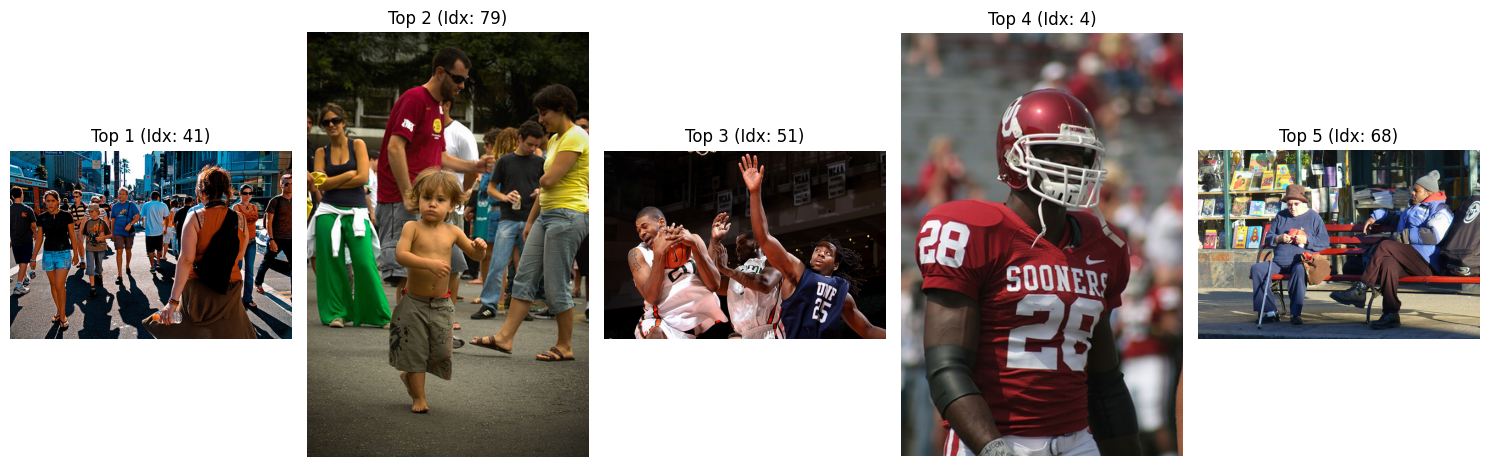

In [10]:

path_tokenizer = "./data/tokenizer_final_retrieval"
tokenizer = AutoTokenizer.from_pretrained(path_tokenizer)


def perform_retrieval(query_text, top_k=3):

    tokens = tokenizer([query_text], padding=True, truncation=True, max_length=40, return_tensors="pt")
    ids, masks = tokens["input_ids"].to(DEVICE), tokens["attention_mask"].to(DEVICE)
    
    with torch.no_grad():
        query_feat = text_model(ids, masks).cpu().numpy().astype('float32')
    
    # Buscar en el índice de imágenes (Texto -> Imagen)
    D_img, I_img = index_img.search(query_feat, top_k)
    
    # Buscar en el índice de texto (Texto -> Texto / Semántica)
    D_txt, I_txt = index_txt.search(query_feat, top_k)
    
    return I_img, I_txt


# 5. DEMO DE CONSULTA CON TOP K
query = "A dog running through the grass"
k =5  # Definimos cuántos queremos ver
best_img_idxs, best_txt_idxs = perform_retrieval(query, top_k=k)

print(f"\n Consulta: '{query}'")
print("=" * 40)

# --- MOSTRAR RESULTADOS DE TEXTO (Text-to-Text) ---
print(f"\n TOP {k} TEXTOS MÁS SIMILARES:")
for i, idx in enumerate(best_txt_idxs[0]):
    caption = test_ds.data['caption_0'][idx]
    print(f"{i+1}. [Index {idx}]: {caption}")

# --- MOSTRAR RESULTADOS DE IMAGEN (Text-to-Image) ---
print(f"\nMOSTRANDO TOP {k} IMÁGENES...")

plt.figure(figsize=(15, 5)) # Ajustamos el ancho según k

for i, idx in enumerate(best_img_idxs[0]):
    plt.subplot(1, k, i + 1)
    
    # Obtenemos la imagen del dataset
    img = test_ds.data['image'][idx]
    
    plt.imshow(img)
    plt.title(f"Top {i+1} (Idx: {idx})")
    plt.axis("off")

plt.tight_layout()
plt.show()

Copiamos la data generada al directorio de nuestro proyecto para usar los pesos actualizados.

In [11]:
!cp -r ./data ./proyectoRetrieval

### OpenClip / CLIP / Mejor modelo LiT  
Medir que modelo distingue mejor los conceptos, si es cercano a 0 es decir ortogonal la definicion/ frase esta mas alejada de la que se esta comparando

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import open_clip
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel

# 1. Parámetros de hardware y rutas (Ajusta según tu expo.md)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
path_final_pesos = "./data/modelo_final_retrieval.pth" 

# Consultas de prueba
queries = [
    "A dog running through the grass",
    "A person cooking food in a kitchen",
    "A child playing with a red ball",
    "An empty street at night"
]
print(f"Ejecutando comparación tripartita en: {device}")

# 2. CARGAR TU MODELO ENTRENADO (Ejemplo con distilbert-base-uncased)
print("\n[1/3] Cargando tu mejor modelo LiT Local...")
try:
    
    tu_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    tu_modelo_texto = TextEncoderModel("distilbert-base-uncased", embed_dim=256)
    
    # Cargar los pesos guardados en la Evaluación 1
    tu_modelo_texto.load_state_dict(torch.load(path_final_pesos, map_location=device))
    tu_modelo_texto = tu_modelo_texto.to(device).eval()
    print(" -> Pesos locales cargados con éxito!")
except Exception as e:
    print(f" -> Nota: No se pudieron cargar tus pesos locales ({e}). Se inicializará la arquitectura base para la simulación.")
    tu_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    tu_modelo_texto = TextEncoderModel("distilbert-base-uncased", embed_dim=256).to(device).eval()

# 3. CARGAR EMBEDDINGS DE MODELOS FUNDACIONALES
print("[2/3] Cargando CLIP Original (OpenAI)...")
model_openai, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer_openai = open_clip.get_tokenizer('ViT-B-32')
model_openai = model_openai.to(device).eval()

print("[3/3] Cargando OpenCLIP (LAION-2B)...")
model_laion, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer_laion = open_clip.get_tokenizer('ViT-B-32')
model_laion = model_laion.to(device).eval()

#Creacion de embedings
tokens_tu_modelo = tu_tokenizer(queries, padding=True, truncation=True, max_length=40, return_tensors="pt").to(device)
tokens_openai = tokenizer_openai(queries).to(device)
tokens_laion = tokenizer_laion(queries).to(device)

with torch.no_grad():
    # 1. Embeddings de tu modelo
    feats_tu_modelo = tu_modelo_texto(tokens_tu_modelo["input_ids"], tokens_tu_modelo["attention_mask"])
    
    # 2. Embeddings OpenAI
    feats_openai = F.normalize(model_openai.encode_text(tokens_openai), dim=-1)
    
    # 3. Embeddings OpenCLIP LAION
    feats_laion = F.normalize(model_laion.encode_text(tokens_laion), dim=-1)

# Calcular Matrices de Inter-Similitud (Producto punto / Coseno)
sim_tu_modelo = (feats_tu_modelo @ feats_tu_modelo.t()).cpu().numpy()
sim_openai = (feats_openai @ feats_openai.t()).cpu().numpy()
sim_laion = (feats_laion @ feats_laion.t()).cpu().numpy()

print("\n--- ANÁLISIS COMPARATIVO DE GEOMETRÍA SEMÁNTICA (3 MODELOS) ---")
comparativa = []
for i in range(len(queries)):
    for j in range(i + 1, len(queries)):
        comparativa.append({
            "Concepto A": queries[i],
            "Concepto B": queries[j],
            "Similitud OpenAI": round(float(sim_openai[i, j]), 4),
            "Similitud LAION": round(float(sim_laion[i, j]), 4),
            "Tu Modelo LiT": round(float(sim_tu_modelo[i, j]), 4)
        })

df_comparativo = pd.DataFrame(comparativa)
display(df_comparativo)

# Métricas de dispersión global en el espacio latente Mientras mas cercano a 0 es que pueden discriminar mejor entre conceptos cruzados (ortogonalidad)
print("\n--- DIAGNÓSTICO DE ORTOGONALIDAD PROMEDIO ---")
print(f"Inter-similitud promedio conceptos cruzados (OpenAI):       {df_comparativo['Similitud OpenAI'].mean():.4f}")
print(f"Inter-similitud promedio conceptos cruzados (LAION):        {df_comparativo['Similitud LAION'].mean():.4f}")
print(f"Inter-similitud promedio conceptos cruzados (Tu LiT Local): {df_comparativo['Tu Modelo LiT'].mean():.4f}")


Ejecutando comparación tripartita en: cuda

[1/3] Cargando tu mejor modelo LiT Local...
 -> ¡Pesos locales cargados con éxito!
[2/3] Cargando CLIP Original (OpenAI)...
[3/3] Cargando OpenCLIP (LAION-2B)...

--- ANÁLISIS COMPARATIVO DE GEOMETRÍA SEMÁNTICA (3 MODELOS) ---


,Concepto A,Concepto B,Similitud OpenAI,Similitud LAION,Tu Modelo LiT
0,A dog running through the grass,A person cooking food in a kitchen,0.6475,0.4032,-0.0520
1,A dog running through the grass,A child playing with a red ball,0.6610,0.4037,0.1197
2,A dog running through the grass,An empty street at night,0.6281,0.3606,-0.1127
3,A person cooking food in a kitchen,A child playing with a red ball,0.7467,0.5107,-0.0696
4,A person cooking food in a kitchen,An empty street at night,0.6876,0.4020,0.1573
5,A child playing with a red ball,An empty street at night,0.6427,0.3236,-0.1580



--- DIAGNÓSTICO DE ORTOGONALIDAD PROMEDIO ---
Inter-similitud promedio conceptos cruzados (OpenAI):       0.6689
Inter-similitud promedio conceptos cruzados (LAION):        0.4006
Inter-similitud promedio conceptos cruzados (Tu LiT Local): -0.0192

[Interpretación para la sustentación]:
Un promedio menor en conceptos cruzados indica un espacio latente más disperso (ortogonal),
lo cual reduce los falsos positivos en tareas de recuperación masiva o bases de datos vectoriales.


## Matriz de similitude semantica

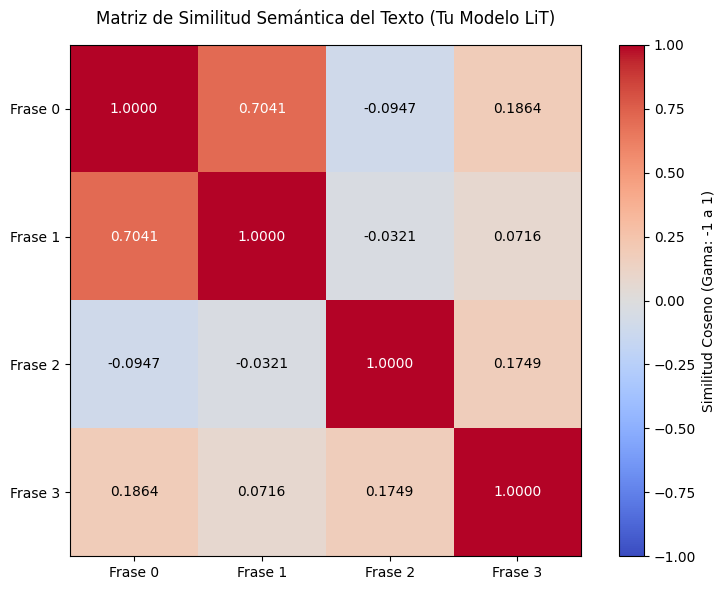

In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


frases_ejemplo = [
    "A happy dog running through the green grass",
    "A golden retriever puppy playing in the park",
    "A chef preparing a gourmet dinner in the kitchen",
    "An empty city street illuminated at night"
]


tu_modelo_texto.eval()

# 2. Tokenizar y transferir al hardware activo (GPU/CPU)
tokens_matriz = tu_tokenizer(
    frases_ejemplo, 
    padding=True, 
    truncation=True, 
    max_length=40, 
    return_tensors="pt"
).to(device)

# 3. Inferencia: Extracción de características y normalización L2 obligatoria
with torch.no_grad():
    embeddings_texto = tu_modelo_texto(tokens_matriz["input_ids"], tokens_matriz["attention_mask"])
    matriz_similitud = (embeddings_texto @ embeddings_texto.t()).cpu().numpy()

# 4. Renderizar la Matriz de Similitud Térmica
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(matriz_similitud, cmap="coolwarm", vmin=-1.0, vmax=1.0)
fig.colorbar(cax, label="Similitud Coseno (Gama: -1 a 1)")

# Configurar etiquetas de los ejes
ax.set_xticks(np.arange(len(frases_ejemplo)))
ax.set_yticks(np.arange(len(frases_ejemplo)))
ax.set_xticklabels([f"Frase {i}" for i in range(len(frases_ejemplo))])
ax.set_yticklabels([f"Frase {i}" for i in range(len(frases_ejemplo))])
plt.xticks(rotation=0)

# Añadir los valores numéricos exactos dentro de cada celda para la sustentación
for i in range(len(frases_ejemplo)):
    for j in range(len(frases_ejemplo)):
        ax.text(j, i, f"{matriz_similitud[i, j]:.4f}", ha="center", va="center", 
                color="white" if abs(matriz_similitud[i, j]) > 0.5 else "black")

plt.title("Matriz de Similitud Semántica del Texto (Tu Modelo LiT)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()



## Ejemplo zero shot / image - text

=== EVALUACIÓN DE CLASIFICACIÓN ZERO-SHOT ===
 -> Caption Real de referencia en Dataset: 'The dogs are in the snow in front of a fence .'
------------------------------------------------------------
DISTRIBUCIÓN DE SCORES POR CANDIDATO:
 * Clase: dog      | Prompt: 'a photo of a dog in a scene   ' -> Similitud: 0.0217
 * Clase: kitchen  | Prompt: 'a photo of a kitchen in a scene' -> Similitud: -0.1186
 * Clase: car      | Prompt: 'a photo of a car in a scene   ' -> Similitud: -0.0326
 * Clase: beach    | Prompt: 'a photo of a beach in a scene ' -> Similitud: 0.0430
------------------------------------------------------------
PREDICCIÓN FINAL DEL MODELO: 'BEACH' (Vía Prompt: 'a photo of a beach in a scene')


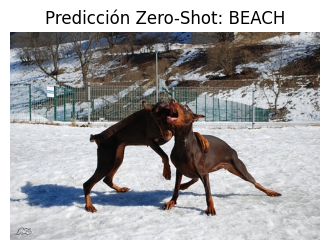

In [16]:
# 1. Definir las clases candidatas para la decisión cerrada
clases_posibles = ["dog", "kitchen", "car", "beach"]

# Prompt para cada clase
prompts_zeroshot = [f"a photo of a {clase} in a scene" for clase in clases_posibles]

# 2. Imagenes de muestra
imagen_muestra = test_ds.data['image'][0]
caption_original = test_ds.data['caption_0'][0]

# Preprocesar la imagen usando la transformación configurada en tu Grid Search
text_image.eval()
imagen_tensor = img_transform(imagen_muestra).unsqueeze(0).to(device)

# 3. Tokenizar
tokens_prompts = tu_tokenizer(
    prompts_zeroshot, 
    padding=True, 
    truncation=True, 
    max_length=40, 
    return_tensors="pt"
).to(device)

# 4. Inferencia Dual (Imagen vs Múltiples Textos)
with torch.no_grad():
    # Visual
    embedding_visual = text_image(imagen_tensor) 
    # Texto
    embeddings_prompts = tu_modelo_texto(tokens_prompts["input_ids"], tokens_prompts["attention_mask"])
    
    # Score Coseno
    scores_zeroshot = (embedding_visual @ embeddings_prompts.t()).squeeze(0).cpu().numpy()

# 5. El mas cercano
indice_prediccion = np.argmax(scores_zeroshot)
clase_predicha = clases_posibles[indice_prediccion]
prompt_ganador = prompts_zeroshot[indice_prediccion]

# 6. Mostrar diagnóstico en pantalla
print("=== EVALUACIÓN DE CLASIFICACIÓN ZERO-SHOT ===")
print(f" -> Caption Real de referencia en Dataset: '{caption_original}'")
print("-" * 60)
print("DISTRIBUCIÓN DE SCORES POR CANDIDATO:")
for clase, prompt, score in zip(clases_posibles, prompts_zeroshot, scores_zeroshot):
    print(f" * Clase: {clase:<8} | Prompt: '{prompt:<30}' -> Similitud: {score:.4f}")

print("-" * 60)
print(f"PREDICCIÓN FINAL DEL MODELO: '{clase_predicha.upper()}' (Vía Prompt: '{prompt_ganador}')")

# Opcional: Visualizar la imagen evaluada para contrastar en vivo
plt.figure(figsize=(4, 4))
plt.imshow(imagen_muestra)
plt.title(f"Predicción Zero-Shot: {clase_predicha.upper()}")
plt.axis("off")
plt.show()